# 06 · K-Means clustering: `src/clustering/_kmeans.py`

Tests for `KMeans`: Lloyd's algorithm with K-Means++ initialisation, mini-batch mode, convergence histories and input validation.

| Data | Source | What it tests |
|---|---|---|
| Gaussian blobs with known centres | generated | recovers the true centres; the objective never increases |
| 20 000-point blobs | generated | mini-batch vs full-batch quality |
| Iris, Digits | scikit-learn, bundled | agreement with true labels (ARI) vs scikit-learn's `KMeans` |
| *China* photo (427 × 640 px) | scikit-learn, bundled | colour quantisation (image compression) |
| Dry Bean (13 611 × 16, 7 varieties) | **online** (UCI id 602) | real-world clustering quality |

**ARI (adjusted Rand index)** measures how well clusters match the true classes: 1 means perfect, 0 means no better than random.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, cluster as skcluster
from sklearn.metrics import adjusted_rand_score as ari
from sklearn.preprocessing import StandardScaler

from _testkit import SEED, Checks, load_online, timed
from src.clustering._kmeans import KMeans

checks = Checks("06 k-means")

## 1. Recovering known cluster centres

In [2]:
TRUE_CENTERS = np.array([[-5, -5], [0, 5], [5, -2], [6, 6]], dtype=float)
X_blob, y_blob = datasets.make_blobs(n_samples=1200, centers=TRUE_CENTERS, cluster_std=0.8, random_state=SEED)

km = KMeans(n_clusters=4, random_state=SEED)
checks.check("fit() returns self", km.fit(X_blob) is km)

# Match every true centre to its nearest learned centre.
dist = np.linalg.norm(TRUE_CENTERS[:, None, :] - km.cluster_centers_[None, :, :], axis=2)
checks.check("each true centre has its own learned centre", len(set(dist.argmin(axis=1))) == 4)
checks.at_most("learned centres within 0.15 of the true centres", dist.min(axis=1).max(), 0.15)
checks.at_least("ARI with the true labels", ari(y_blob, km.labels_), 0.99)
checks.check("centroids / labels aliases", km.centroids is km.cluster_centers_ and km.labels is km.labels_)

✅ fit() returns self
✅ each true centre has its own learned centre
✅ learned centres within 0.15 of the true centres  (0.1040 ≤ 0.15)
✅ ARI with the true labels  (1.0000 ≥ 0.99)
✅ centroids / labels aliases


True

## 2. Internal consistency

- `inertia_` should equal the WCSS recomputed from the labels and centres.
- Every label should point to the nearest centre, so `predict(X_train)` must reproduce `labels_`.
- Lloyd's algorithm never increases the objective, so the WCSS history must be non-increasing.

✅ inertia_ == recomputed WCSS  (max |Δ| = 0.00e+00)
✅ labels_ are the nearest centres
✅ predict(X_train) == labels_
✅ WCSS history is non-increasing (Lloyd)
✅ history lengths == n_iter_
✅ converged: last centroid movement < tol


/tmp/ipykernel_165767/382426135.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].set(title="Centroid movement per iteration", xlabel="iteration"); ax[1].legend()


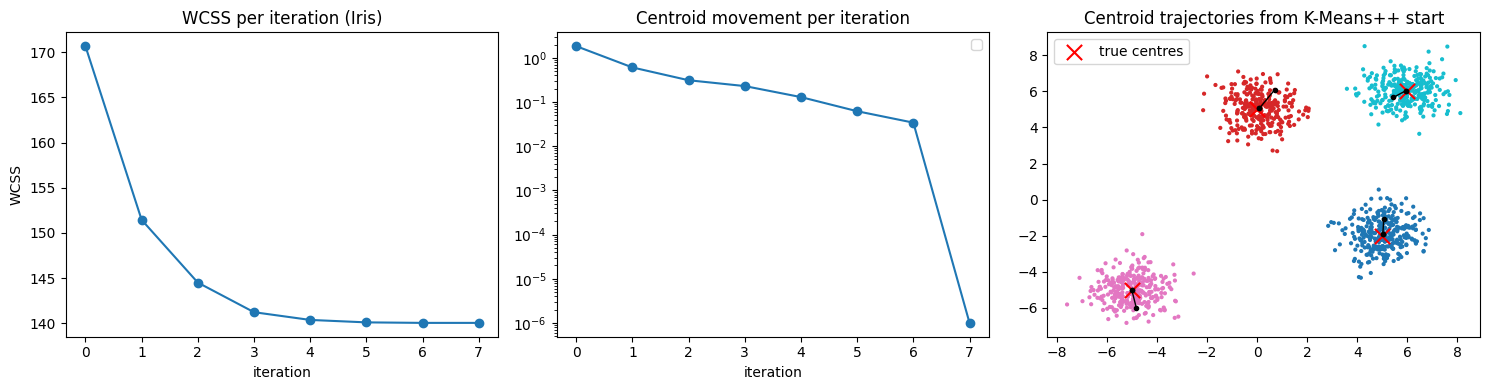

In [3]:
wcss = sum(((X_blob[km.labels_ == k] - c) ** 2).sum() for k, c in enumerate(km.cluster_centers_))
checks.close("inertia_ == recomputed WCSS", km.inertia_, wcss, rtol=1e-9)
nearest = np.argmin(((X_blob[:, None, :] - km.cluster_centers_[None]) ** 2).sum(-1), axis=1)
checks.check("labels_ are the nearest centres", np.array_equal(km.labels_, nearest))
checks.check("predict(X_train) == labels_", np.array_equal(km.predict(X_blob), km.labels_))

X_iris = StandardScaler().fit_transform(datasets.load_iris().data)
km_i = KMeans(n_clusters=3, random_state=1).fit(X_iris)
hist = np.array(km_i.wcss_history)
checks.check("WCSS history is non-increasing (Lloyd)", np.all(np.diff(hist) <= 1e-9))
checks.check("history lengths == n_iter_",
             len(km_i.wcss_history) == len(km_i.centroid_history_) == len(km_i.centroid_movement_history_) == km_i.n_iter_)
checks.check("converged: last centroid movement < tol", km_i.n_iter_ < km_i.max_iter and km_i.centroid_movement_history_[-1] < km_i.tol)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(hist, "o-"); ax[0].set(title="WCSS per iteration (Iris)", xlabel="iteration", ylabel="WCSS")
ax[1].semilogy(np.maximum(km_i.centroid_movement_history_, 1e-6), "o-")   # floor: final movement can be exactly 0; ax[1].axhline(km_i.tol, color="r", ls="--", label="tol")
ax[1].set(title="Centroid movement per iteration", xlabel="iteration"); ax[1].legend()
ax[2].scatter(X_blob[:, 0], X_blob[:, 1], c=km.labels_, s=4, cmap="tab10")
path = np.array(km.centroid_history_ + [km.cluster_centers_])
for k in range(4):
    ax[2].plot(path[:, k, 0], path[:, k, 1], "k.-", lw=1)
ax[2].scatter(*TRUE_CENTERS.T, marker="x", c="red", s=120, label="true centres"); ax[2].legend()
ax[2].set_title("Centroid trajectories from K-Means++ start")
plt.tight_layout(); plt.show()

## 3. Determinism and parameters

✅ same random_state → identical centres
✅ a numpy Generator is accepted as random_state
✅ max_iter=1 runs a single iteration
✅ max_iterations= alias sets max_iter
✅ inertia decreases as k grows
✅ elbow method finds k = 4  (elbow at k=4)


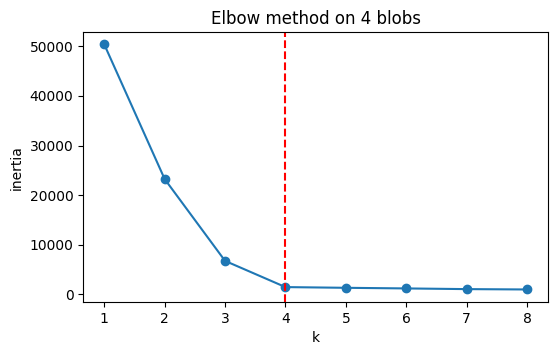

In [4]:
a = KMeans(4, random_state=7).fit(X_blob)
b = KMeans(4, random_state=7).fit(X_blob)
checks.check("same random_state → identical centres", np.array_equal(a.cluster_centers_, b.cluster_centers_))
g = KMeans(4, random_state=np.random.default_rng(7)).fit(X_blob)
checks.check("a numpy Generator is accepted as random_state", g.cluster_centers_.shape == (4, 2))
one = KMeans(4, max_iter=1, random_state=0).fit(X_blob)
checks.check("max_iter=1 runs a single iteration", one.n_iter_ == 1)
checks.check("max_iterations= alias sets max_iter", KMeans(3, max_iterations=17).max_iter == 17)

ks = range(1, 9)
inertias = [KMeans(k, random_state=SEED).fit(X_blob).inertia_ for k in ks]
checks.check("inertia decreases as k grows", np.all(np.diff(inertias) < 0))
drops = -np.diff(inertias)
elbow = int(np.argmax(drops[:-1] / drops[1:])) + 2     # k after which the drop collapses
checks.check("elbow method finds k = 4", elbow == 4, f"elbow at k={elbow}")
plt.figure(figsize=(6, 3.5)); plt.plot(list(ks), inertias, "o-"); plt.axvline(4, color="r", ls="--")
plt.title("Elbow method on 4 blobs"); plt.xlabel("k"); plt.ylabel("inertia"); plt.show()

## 4. Mini-batch mode

On 20 000 points, mini-batch K-Means should reach nearly the same objective as full-batch Lloyd.

> **Speed note:** in this NumPy implementation, full-batch Lloyd is fully vectorised while mini-batch loops over batches and centroids in Python, so mini-batch is *slower* at this size. It pays off only when the full `n × k` distance matrix is too expensive to compute every iteration.

In [5]:
X_big, _ = datasets.make_blobs(n_samples=20_000, centers=8, n_features=5, cluster_std=1.5, random_state=SEED)
with timed("full-batch Lloyd"):
    full = KMeans(8, random_state=SEED).fit(X_big)
with timed("mini-batch (batch_size=512)"):
    mini = KMeans(8, batch_size=512, random_state=SEED).fit(X_big)
print(f"inertia  full: {full.inertia_:.1f} | mini-batch: {mini.inertia_:.1f}")
checks.at_most("mini-batch inertia within 2 % of full batch", mini.inertia_ / full.inertia_ - 1, 0.02)
checks.check("mini-batch labels are nearest-centre labels", np.array_equal(mini.labels_, mini.predict(X_big)))

⏱️ full-batch Lloyd: 0.33s


⏱️ mini-batch (batch_size=512): 1.78s
inertia  full: 502794.0 | mini-batch: 502834.6
✅ mini-batch inertia within 2 % of full batch  (0.0001 ≤ 0.02)
✅ mini-batch labels are nearest-centre labels


True

## 5. Comparison with scikit-learn on real data

Our K-Means runs a single K-Means++ initialisation. scikit-learn's default keeps the best of several (`n_init`). On these datasets one good start is usually enough.

✅ Iris (scaled): inertia within 3 % of sklearn (n_init=10)  (0.0000 ≤ 0.03)
✅ Iris (scaled): |ARI ours − sklearn|  (0.0000 ≤ 0.1)
✅ Digits: inertia within 3 % of sklearn (n_init=10)  (0.0243 ≤ 0.03)
✅ Digits: |ARI ours − sklearn|  (0.0061 ≤ 0.1)


,dataset,ARI ours,ARI sklearn,inertia ours / sklearn
0,Iris (scaled),0.6201,0.6201,1.0000
1,Digits,0.6730,0.6669,1.0243


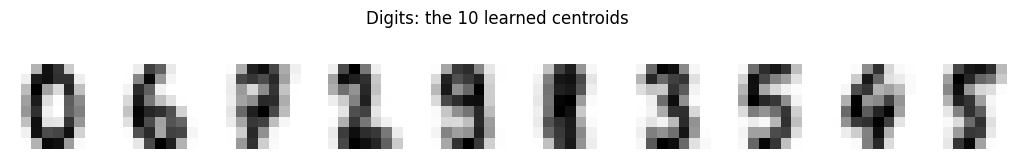

In [6]:
rows = []
for name, X, y, k in [("Iris (scaled)", X_iris, datasets.load_iris().target, 3),
                      ("Digits", datasets.load_digits().data, datasets.load_digits().target, 10)]:
    ours = KMeans(k, random_state=SEED).fit(X)
    ref = skcluster.KMeans(k, n_init=10, random_state=SEED).fit(X)
    rows.append({"dataset": name, "ARI ours": ari(y, ours.labels_), "ARI sklearn": ari(y, ref.labels_),
                 "inertia ours / sklearn": ours.inertia_ / ref.inertia_})
    checks.at_most(f"{name}: inertia within 3 % of sklearn (n_init=10)", rows[-1]["inertia ours / sklearn"] - 1, 0.03)
    checks.at_most(f"{name}: |ARI ours − sklearn|", abs(rows[-1]["ARI ours"] - rows[-1]["ARI sklearn"]), 0.1)
display(pd.DataFrame(rows).round(4))

dig = datasets.load_digits()
km_d = KMeans(10, random_state=SEED).fit(dig.data)
fig, axes = plt.subplots(1, 10, figsize=(13, 1.6))
for k, ax in enumerate(axes):
    ax.imshow(km_d.cluster_centers_[k].reshape(8, 8), cmap="gray_r"); ax.axis("off")
plt.suptitle("Digits: the 10 learned centroids", y=1.1); plt.show()

## 6. Colour quantisation (image compression)

We cluster the photo's RGB pixels into *k* colours and redraw every pixel in its cluster's colour. With more colours the reconstruction error should fall.

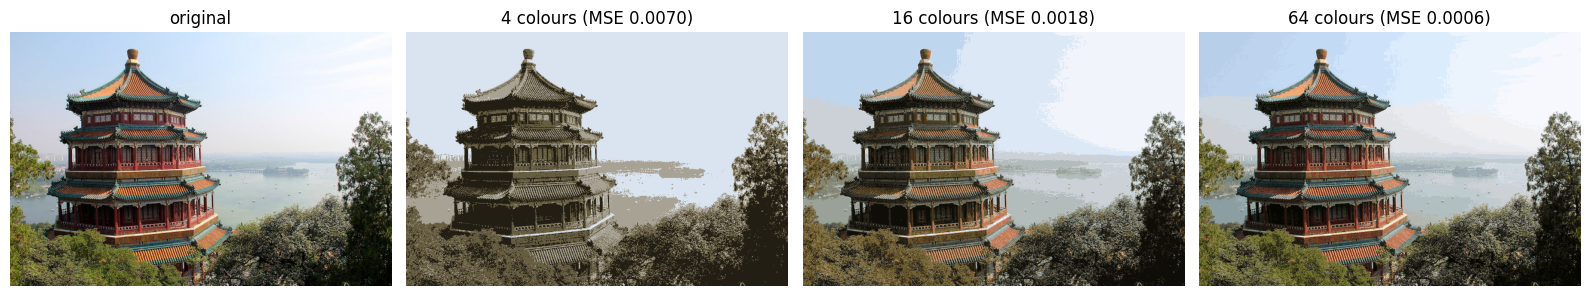

✅ more colours → lower reconstruction error


True

In [7]:
img = datasets.load_sample_image("china.jpg") / 255.0
pixels = img.reshape(-1, 3)
sample = pixels[np.random.default_rng(SEED).choice(len(pixels), 5000, replace=False)]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
axes[0].imshow(img); axes[0].set_title("original"); axes[0].axis("off")
errors = []
for ax, k in zip(axes[1:], [4, 16, 64]):
    q = KMeans(k, random_state=SEED).fit(sample)
    recon = q.cluster_centers_[q.predict(pixels)].reshape(img.shape)
    errors.append(float(np.mean((recon - img) ** 2)))
    ax.imshow(recon); ax.set_title(f"{k} colours (MSE {errors[-1]:.4f})"); ax.axis("off")
plt.tight_layout(); plt.show()
checks.check("more colours → lower reconstruction error", errors[0] > errors[1] > errors[2])

## 7. Real data (online): Dry Bean

13 611 bean images described by 16 shape features, from 7 bean varieties. The features are standardised first because K-Means is distance-based.

In [8]:
def _dry_bean():
    from ucimlrepo import fetch_ucirepo
    d = fetch_ucirepo(id=602)
    return d.data.features.to_numpy(float), d.data.targets.iloc[:, 0].to_numpy()

bean, online = load_online("Dry Bean (UCI 602)", _dry_bean)
if online:
    Xb, yb = bean
    Xb = StandardScaler().fit_transform(Xb)
    with timed("KMeans k=7 on 13 611 beans"):
        kb = KMeans(7, random_state=SEED).fit(Xb)
    ref = skcluster.KMeans(7, n_init=10, random_state=SEED).fit(Xb)
    print(f"ARI ours {ari(yb, kb.labels_):.4f} | sklearn {ari(yb, ref.labels_):.4f}")
    checks.at_least("Dry Bean: ARI with the true varieties", ari(yb, kb.labels_), 0.6)
    checks.at_most("Dry Bean: inertia within 3 % of sklearn", kb.inertia_ / ref.inertia_ - 1, 0.03)
    display(pd.crosstab(pd.Series(yb, name="variety"), pd.Series(kb.labels_, name="cluster")))
else:
    checks.skip("Dry Bean checks", "dataset unavailable offline")

🌐 Dry Bean (UCI 602): downloaded / loaded from cache
⏱️ KMeans k=7 on 13 611 beans: 0.09s


ARI ours 0.6688 | sklearn 0.6687
✅ Dry Bean: ARI with the true varieties  (0.6688 ≥ 0.6)
✅ Dry Bean: inertia within 3 % of sklearn  (0.0000 ≤ 0.03)


cluster,0,1,2,3,4,5,6
variety,,,,,,,
BARBUNYA,18,0,114,8,1142,0,40
BOMBAY,0,520,0,0,1,0,1
CALI,2,0,25,30,1304,0,269
DERMASON,115,0,500,7,0,2912,12
HOROZ,0,0,49,1661,29,2,187
SEKER,1874,0,98,0,0,52,3
SIRA,24,0,2327,63,5,191,26


## 8. Input validation

In [9]:
X_small = np.random.default_rng(0).normal(size=(50, 2))
checks.raises("n_clusters=0 raises", ValueError, lambda: KMeans(n_clusters=0))
checks.raises("negative tol raises", ValueError, lambda: KMeans(tol=-1))
checks.raises("batch_size=0 raises", ValueError, lambda: KMeans(batch_size=0))
checks.raises("string random_state raises", ValueError, lambda: KMeans(random_state="seed"))
checks.raises("n_clusters > n_samples raises", ValueError, lambda: KMeans(n_clusters=60).fit(X_small))
checks.raises("NaN in X raises", ValueError, lambda: KMeans(2).fit(np.array([[0.0, 1.0], [np.nan, 2.0], [3.0, 4.0]])))
checks.raises("predict before fit raises", ValueError, lambda: KMeans().predict(X_small))

✅ n_clusters=0 raises  (ValueError: n_clusters must be a positive integer.)
✅ negative tol raises  (ValueError: tol must be a non-negative number.)
✅ batch_size=0 raises  (ValueError: batch_size must be a positive integer or None.)
✅ string random_state raises  (ValueError: random_state must be None, an integer, or a numpy.random.Generator.)
✅ n_clusters > n_samples raises  (ValueError: n_clusters (60) cannot exceed n_samples (50).)
✅ NaN in X raises  (ValueError: X must contain only finite values (no NaN or inf).)
✅ predict before fit raises  (ValueError: Model is not fitted; call fit first.)


True

## Summary

In [10]:
checks.summary()

06 k-means: 33 passed, 0 failed, 0 skipped, 0 known bug(s) (33 checks)


,check,status,detail
0,fit() returns self,pass,
1,each true centre has its own learned centre,pass,
2,learned centres within 0.15 of the true centres,pass,0.1040 ≤ 0.15
3,ARI with the true labels,pass,1.0000 ≥ 0.99
4,centroids / labels aliases,pass,
5,inertia_ == recomputed WCSS,pass,max |Δ| = 0.00e+00
6,labels_ are the nearest centres,pass,
7,predict(X_train) == labels_,pass,
8,WCSS history is non-increasing (Lloyd),pass,
9,history lengths == n_iter_,pass,
